In [1]:
import torch
import torch.nn.functional as F


### Simulation Config

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

simulation_config ={
	
	"Simulation": {
		
		"unit": "um",
		
		"voxel_resolution": [0.1075, 0.1075, 0.1075],
		"n_voxels": [250,250,250],
		"n_background": 1.334,
		"sim_mask": None
		
	}
}

### Utils

In [31]:
def unit_conversion(from_unit, to_unit):
    """
    Return the conversion factor to convert a value from one length unit to another.
    
    Example:
        x * unit_conversion("m", "um")  # converts x meters to um
    """
    units = {
        "m": 1.0,
        "cm": 0.01,
        "mm": 0.001,
        "um": 1e-6,
        "nm": 1e-9
    }
    
    if from_unit not in units or to_unit not in units:
        raise ValueError(f"Unsupported units: {from_unit}, {to_unit}")
    
    return units[from_unit] / units[to_unit]

### Voxel Object Definition

In [32]:
class VoxelObject:
    def __init__(self, spatial_resolution, unit="um"):

        ## Properties ##
        self.unit = unit
        self.spatial_resolution = torch.tensor(spatial_resolution, dtype=dtype, device=device)
        

    def forward(self, obj_shape=(250,250,250)):
        grid = torch.zeros(obj_shape, dtype=dtype, device=device) + 1.334

        grid[100:150, 100:150, 100:150] = 1.5
        self.data = grid

        self.obj_shape = torch.tensor(self.data.shape, dtype=torch.int32, device=device)

voxel_object = VoxelObject(spatial_resolution=[0.1075, 0.1075, 0.1075], unit="um")
voxel_object.forward()

### Smaple Pose

In [33]:
def normalize(quaternions: torch.Tensor) -> torch.Tensor:
    """Normalize quaternions to unit length.
    Args:
        quaternions: Tensor of shape (..., 4).
    Returns:
        Tensor of shape (..., 4): normalized quaternions.
    """
    quaternions = F.normalize(quaternions, p=2, dim=-1)
    return quaternions

def to_matrix(quaternions, dtype):
    """
    Convert quaternions to rotation matrices.

    Args:
        quaternions: Tensor of shape (..., 4), real part first (w, x, y, z).

    Returns:
        Tensor of shape (..., 3, 3): rotation matrices.
    """
    # Normalize to unit quaternions
    quaternions = normalize(quaternions)

    w, x, y, z = torch.unbind(quaternions, dim=-1)
    two_s = 2.0 / (quaternions * quaternions).sum(-1, keepdim=True)

    o = torch.stack([
        1 - two_s * (y * y + z * z),
        two_s * (x * y - z * w),
        two_s * (x * z + y * w),

        two_s * (x * y + z * w),
        1 - two_s * (x * x + z * z),
        two_s * (y * z - x * w),

        two_s * (x * z - y * w),
        two_s * (y * z + x * w),
        1 - two_s * (x * x + y * y),
    ], dim=-1)

    R = o.reshape(quaternions.shape[:-1] + (3, 3))
    R = R.to(dtype=dtype)
    return R

In [34]:
r = torch.tensor([5.0, 0.0, 0.0], dtype=dtype, device=device)


deg = torch.tensor([35])
q = torch.tensor([torch.cos(deg/2), 0, 0,  torch.sin(deg/2)], device=device) # rotation quaternion (w, x, y, z)
R = to_matrix(q, dtype=dtype)


offset = torch.tensor([0.0, 0.0, 0.0], dtype=dtype, device=device)

### Simulation Space

In [35]:
class SimulationSpace:
    def __init__(self, simulation_config,
                 dtype=torch.float64, device=None, requires_grad=True):
        
        """
        Simulation Space in which we place our Voxel Object and through which we propergate our wavefield

         -------
         grid_shape: list
            Number of Voxels in [nx, ny, ny]
        
        spatial_resolution: list
            Physical size of each Voxel [dx, dy, dz]

        n_background: float
            Reflective Index of the Simulation Space without Object

        dtype: torch.type
            Precision/datatype used within the simulation

        device: torch.device
            CUDA or CPU. If set to None it will prioritize CUDA if available

        requires_grad: bool
            Flag enableling backpropergation through the simulation

        """

        ## Data Settings ##
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device
        self.dtype = dtype



        ### Simulation Space & Wavefield Propagation Settings ###
        self.sim_unit = simulation_config["Simulation"]["unit"]
        self.spatial_resolution = simulation_config["Simulation"]["voxel_resolution"]  
        self.grid_shape = simulation_config["Simulation"]["n_voxels"]
        self.n_background = simulation_config["Simulation"]["n_background"]
    
        self.sim_space_center = (torch.tensor(self.grid_shape, device=self.device) * torch.tensor(self.spatial_resolution, device=self.device)) / 2

        # 3D Voxel Grid
        self.nx, self.ny, self.nz = self.grid_shape
        self.dx, self.dy, self.dz = self.spatial_resolution
        self.n_0 = torch.tensor([self.n_background], device=self.device, dtype=self.dtype)
        
        self.grid = torch.ones([self.nx, self.ny, self.nz], device=self.device, dtype=self.dtype) * self.n_0
        self.grid.requires_grad_(requires_grad)

        x = torch.linspace(0, self.nx * self.dx, self.nx, device=self.device, dtype=self.dtype)
        y = torch.linspace(0, self.ny * self.dy, self.ny, device=self.device, dtype=self.dtype)
        z = torch.linspace(0, self.nz * self.dz, self.nz, device=self.device, dtype=self.dtype)
        grid_x, grid_y, grid_z = torch.meshgrid(x, y, z, indexing='ij')

        self.coords = torch.stack([grid_x, grid_y, grid_z], dim=-1) 


        # Voxel Object - has to be set manualy by default (see set voxel object)
        self.voxel_object = None


        # Simulation Mask
        sim_mask = simulation_config["Simulation"].get("sim_mask", None)
        if sim_mask is None:
            sim_mask = {"type": "empty", "size": None}
        sim_mask_type = sim_mask.get("type", None)
        sim_mask_size = sim_mask.get("size", None)
        mask_fn = {"sphere": self.sphere_mask,
                   "rect": self.rect_mask}
        
        self.mask_fn = mask_fn.get(sim_mask_type, self.empty_mask)
        if self.mask_fn == self.empty_mask:
            sim_mask_size = None
        self.sim_mask_size = sim_mask_size


    def __repr__(self):
        ret = ""
        ret += "-- Simulation Space --\n"
        ret += f" SimSpace unit: {self.sim_unit}\n"
        ret += f" Grid Shape: [{self.nx}, {self.ny}, {self.nz}]\n"
        ret += f" Voxel resolution: [{self.dx}, {self.dy}, {self.dz}] {self.sim_unit}\n"
        ret += f" Background RI value: {self.n_0.item()}\n"
        ret += f" Sim Mask: {self.mask_fn.__name__}, size: {self.sim_mask_size}\n"

        return ret


    def set_voxel_object(self, voxel_object):
        """Set the Voxel Object, that we want to add to our Simulation Space.
        Currently only supports single Object"""

        # RI Volume
        self.voxel_object = voxel_object.data

        # Object Size
        self.obj_shape = voxel_object.obj_shape

        # Convert Object spatial resolution units to Simulation units
        conversion_factor = unit_conversion(from_unit = voxel_object.unit, to_unit = self.sim_unit)
        self.obj_spatial_res = voxel_object.spatial_resolution * conversion_factor

        # Object center in physical unit
        self.obj_center = (self.obj_shape * self.obj_spatial_res) / 2



    def masked_add_voxel_object(self, voxel_object, position, offset, rotation, pose_unit):
        """ 
        Place and Rotate the Voxel Object into Simulation Space.
        Only use backwards mapping and interpolation in a small region around the object to speed up computation.
        Region is defined by a masked centered around the object position.
        The rest of the grid is filled with the background value.
        -------
        voxel_object: voxel_object.VoxelObject
            Voxel Object to be placed into the Simulation Space

        position: torch.tensor
            Position in physical coordinates at which the center of the Voxel Object

        offset: toch.tensor
            Translation vector to define the new center of the Voxel Object. By default is the Center of the Voxel Object its center of mass

        rotation: torch.tensor
            Rotation Matrix defining axis and angle of the Rotation.

        ------

        self.grid: torch.tensor
            Simulation Space / RI Distribution with the added Voxel Object 

        """
        
        # Voxel Object Parameters
        self.set_voxel_object(voxel_object)

        # Convert Position/Offset units to Simulation units
        conversion_factor = unit_conversion(from_unit=pose_unit, to_unit=self.sim_unit)
        position = position * conversion_factor + self.sim_space_center # Translation
        offset = offset * conversion_factor

        # Shift Center of the Voxel Object
        obj_center = self.obj_center + offset

        # Grid coordinates (nx, ny, nz, 3)
        coords = self.coords.clone()

        

        # Create Mask
        position_grid_idx = torch.round(position / torch.tensor([self.dx, self.dy, self.dz], device=self.device)).to(torch.int)
        #radius = 110
        #mask = sphere_mask(self.grid.shape, position_grid_idx, radius, device=self.device)
        mask = self.mask_fn(position_grid_idx, self.sim_mask_size, device=self.device) 
        mask_flat = mask.bool().view(-1)


        coords_flat = coords.view(-1, 3)[mask_flat]


        # --- Backwards Mapping to Voxel Object Space ---
        coords_flat -= position  # Translate to object position
        coords_flat = coords_flat @ rotation.T  # Rotate to object space

        # Convert to voxel object coordinates
        grid_coords = coords_flat / self.obj_spatial_res
        grid_coords += obj_center / self.obj_spatial_res  

        # --- Normalize for Grid Sample ---
        grid_coords = grid_coords[..., [2, 1, 0]]  # Swap to match (D, H, W)
        grid_coords = (grid_coords / (self.obj_shape - 1)) * 2 - 1  # Normalize to [-1, 1]

        # --- Identify valid regions ---
        valid_mask = ((grid_coords >= -1) & (grid_coords <= 1)).all(dim=-1)

        # Reshape for grid_sample
        grid_coords = grid_coords.unsqueeze(0).unsqueeze(0).unsqueeze(0)  # (N, 1, 1, 1, 3)
        voxel_object_tensor = self.voxel_object.unsqueeze(0).unsqueeze(0)  # (1, 1, Dx, Dy, Dz)

        # --- Perform Trilinear Interpolation ---
        interpolated_grid = F.grid_sample(
            voxel_object_tensor,
            grid_coords,
            mode='bilinear',
            align_corners=True
        ).squeeze()

        # Apply default value for invalid points
        interpolated_grid = torch.where(valid_mask, interpolated_grid, self.n_0)

        full_grid = torch.full(
            self.coords.shape[:-1],
            fill_value=self.n_0.item(),
            device=self.device,
            dtype=interpolated_grid.dtype
        )
        full_grid.view(-1)[mask_flat] = interpolated_grid
        self.grid = full_grid


        return self.grid



    def sphere_mask(self, center, size, device):
        Z, Y, X = torch.meshgrid(torch.arange(self.nz, device=device), 
                                torch.arange(self.ny, device=device), 
                                torch.arange(self.nx, device=device), indexing='ij')
        dist_from_center = torch.sqrt((X - center[2])**2 + (Y - center[1])**2 + (Z - center[0])**2)
        mask = (dist_from_center <= size).float()
        return mask


    def rect_mask(self, center, size, device):

        # Square mask
        if isinstance(size, (int, float)):
            size = [size, size, size]
        size = torch.tensor(size, device=device)

        Z, Y, X = torch.meshgrid(torch.arange(self.nz, device=device), 
                                torch.arange(self.ny, device=device), 
                                torch.arange(self.nx, device=device), indexing='ij')
        mask = ((X >= (center[2] - size[2]/2)) & (X <= (center[2] + size[2]/2)) &
                (Y >= (center[1] - size[1]/2)) & (Y <= (center[1] + size[1]/2)) &
                (Z >= (center[0] - size[0]/2)) & (Z <= (center[0] + size[0]/2))).float()
        return mask

    def empty_mask(self, center, size, device):
        mask = torch.ones(self.grid.shape, device=device)
        return mask
    

simspace = SimulationSpace(simulation_config, dtype=dtype, device=device, requires_grad=False)


Text(0, 0.5, 'X (um)')

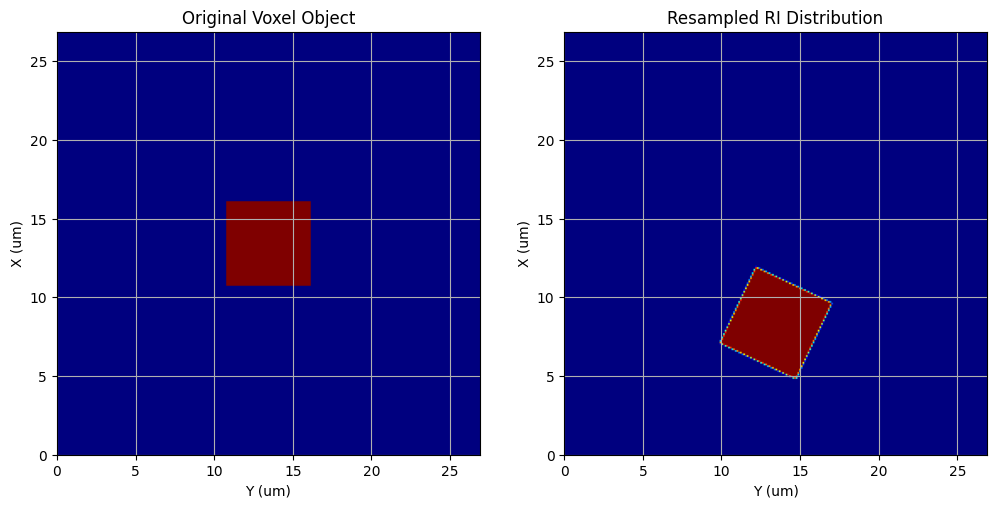

In [36]:
ri_dist = simspace.masked_add_voxel_object(voxel_object, r, offset, R, "um")


slice_index = 125

import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

extend = [0, voxel_object.obj_shape[0].cpu()*voxel_object.spatial_resolution[0].cpu(), 0, voxel_object.obj_shape[1].cpu()*voxel_object.spatial_resolution[1].cpu()]


axs[0].imshow(voxel_object.data[:,:,slice_index].cpu(), cmap='jet', extent=extend)
axs[0].set_title('Original Voxel Object')
axs[0].grid()
axs[0].set_xlabel('Y (um)')
axs[0].set_ylabel('X (um)')

axs[1].imshow(ri_dist[:,:,slice_index].cpu(), cmap='jet', extent=extend)
axs[1].set_title('Resampled RI Distribution')
axs[1].grid()
axs[1].set_xlabel('Y (um)')
axs[1].set_ylabel('X (um)')